# MIT 805 Part 2: NYC high-volume ride-hailing
Group 10 — Fateh Cheballah and Mpendulo Sibeko

How did recorded HVFHV trip volumes, base fares and driver pay change around the introduction of congestion pricing on 5 January 2025, and how did CBD-core pickups differ from pickups in the outer boroughs?

We compare time trends, trip characteristics and operators using PySpark. The aim is to identify changes relevant to vehicle positioning, passenger charges and driver remuneration. These are descriptive comparisons: a change after January is not, by itself, an effect of the policy.

Part 1 used Polars for June 2026 EDA. Its recorded dataset sizes remain 37.58 GB raw (89 files, February 2019–June 2026), 12.00 GB working (26 files, May 2024–June 2026), and 3.36 GB for the proposed seven-file processing subset (December 2025–June 2026). The Part 1 code divided bytes by 1024³ while labelling the results GB; those historical figures are retained here, with the convention stated.

Part 2 instead processes July 2024–June 2025, within the established working window. The change gives observations on both sides of the introduction date. The downloaded files are measured below; their size is not assumed to equal the Part 1 processing size. Twelve months allow us to inspect trends, but comparing different seasons does not control seasonality.


## 1. Colab setup
Use a fresh Python CPU runtime; a GPU is not needed. Run the notebook in order. Downloads and repeated Spark scans can take time. All trip-level filtering, joins and aggregation stay in Spark. Only small grouped results are brought into Python for plotting.

The default runs Spark locally across the Colab CPU cores. It demonstrates partitions, tasks and shuffles on one machine, not a multi-machine cluster. The recorded master and runtime details should be reported accurately.


In [1]:
%pip install -q pyspark==3.5.3 requests pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.3 which is incompatible.


In [2]:
from pathlib import Path
from datetime import date, datetime, timezone
from functools import reduce
from operator import add
import contextlib, io, json, os, platform, shutil, subprocess, time
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pyspark.sql import SparkSession, functions as F
from pyspark import StorageLevel

PROJECT_ROOT = Path('/content/mit805_part2') if Path('/content').exists() else Path.cwd() / 'mit805_part2_run'
DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR = PROJECT_ROOT / 'figures'
OUT_DIR = PROJECT_ROOT / 'output'
EVIDENCE_DIR = OUT_DIR / 'evidence'
EVENT_DIR = EVIDENCE_DIR / 'spark-events'
for folder in [DATA_DIR, FIG_DIR, OUT_DIR, EVIDENCE_DIR, EVENT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

START, POLICY, END = date(2024, 7, 1), date(2025, 1, 5), date(2025, 7, 1)
MONTHS = [f'2024-{m:02d}' for m in range(7, 13)] + [f'2025-{m:02d}' for m in range(1, 7)]
PERIOD_DAYS = {'pre': (POLICY - START).days, 'post': (END - POLICY).days}
print('Pre: 1 July 2024–4 January 2025; post: 5 January–30 June 2025')
print('Calendar days:', PERIOD_DAYS)
print('Outputs:', PROJECT_ROOT)
print(subprocess.run(['java', '-version'], capture_output=True, text=True).stderr)


Pre: 1 July 2024–4 January 2025; post: 5 January–30 June 2025
Calendar days: {'pre': 188, 'post': 177}
Outputs: /content/mit805_part2
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)



In [3]:
# Use a fresh runtime if another Spark session is already running.
spark = (SparkSession.builder.master('local[*]')
    .appName('MIT805-HVFHV-Part2')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '32')
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.sql.session.timeZone', 'America/New_York')
    .config('spark.eventLog.enabled', 'true')
    .config('spark.eventLog.compress', 'false')
    .config('spark.eventLog.dir', EVENT_DIR.resolve().as_uri())
    .getOrCreate())
sc = spark.sparkContext
sc.setLogLevel('WARN')
runtime = {
    'run_utc': datetime.now(timezone.utc).isoformat(),
    'python': platform.python_version(), 'spark': spark.version,
    'master': sc.master, 'application_id': sc.applicationId,
    'default_parallelism': sc.defaultParallelism,
    'shuffle_partitions': spark.conf.get('spark.sql.shuffle.partitions'),
    'session_timezone': spark.conf.get('spark.sql.session.timeZone'),
    'spark_ui': sc.uiWebUrl, 'cpu_count': os.cpu_count(),
    'raw_part1_reported_GB': 37.58, 'working_part1_reported_GB': 12.00,
    'part1_proposed_processing_GB': 3.36,
    'historical_size_divisor': 1024**3,
    'period_calendar_days': PERIOD_DAYS,
}
print(json.dumps(runtime, indent=2))
(OUT_DIR / 'runtime.json').write_text(json.dumps(runtime, indent=2))


{
  "run_utc": "2026-10-03T23:55:41.019338+00:00",
  "python": "3.13.15",
  "spark": "3.5.3",
  "master": "local[*]",
  "application_id": "local-1791071738952",
  "default_parallelism": 2,
  "shuffle_partitions": "32",
  "session_timezone": "America/New_York",
  "spark_ui": "http://e945b3135e98:4040",
  "cpu_count": 2,
  "raw_part1_reported_GB": 37.58,
  "working_part1_reported_GB": 12.0,
  "part1_proposed_processing_GB": 3.36,
  "historical_size_divisor": 1073741824,
  "period_calendar_days": {
    "pre": 188,
    "post": 177
  }
}


538

## 2. Download and measure the processing subset
The measurement uses the sizes of the actual local Parquet files, not estimates from HTTP headers. We print decimal GB and binary GiB and require at least 3 GiB, which also exceeds 3 decimal GB. Only these twelve explicit paths are read by Spark.

Downloads use temporary files and check Parquet markers before reusing a file. This checks obvious truncation, not every data page; Spark must still read the files successfully. Keep the manifest with the report evidence. Local file reuse allows a disconnected runtime to work if the data is already present.


In [4]:
http = requests.Session()
retry = Retry(total=4, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
http.mount('https://', HTTPAdapter(max_retries=retry))

def parquet_ok(path):
    if not path.exists() or path.stat().st_size < 12:
        return False
    with path.open('rb') as f:
        start = f.read(4)
        f.seek(-4, 2)
        return start == b'PAR1' and f.read(4) == b'PAR1'

def download(url, dest, parquet=False):
    if dest.exists() and (parquet_ok(dest) if parquet else dest.stat().st_size > 0):
        return
    part = dest.with_suffix(dest.suffix + '.part')
    print('Downloading', dest.name)
    with http.get(url, stream=True, timeout=(30, 180)) as response:
        response.raise_for_status()
        with part.open('wb') as f:
            for block in response.iter_content(8 * 1024 * 1024):
                if block:
                    f.write(block)
        expected = response.headers.get('Content-Length')
        if expected and not response.headers.get('Content-Encoding'):
            assert part.stat().st_size == int(expected), f'Incomplete download: {dest.name}'
    if parquet:
        assert parquet_ok(part), f'Invalid Parquet markers: {dest.name}'
    part.replace(dest)

base_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/'
manifest = []
for month in MONTHS:
    path = DATA_DIR / f'fhvhv_tripdata_{month}.parquet'
    url = base_url + path.name
    download(url, path, parquet=True)
    manifest.append({'month': month, 'filename': path.name, 'url': url,
                     'bytes': path.stat().st_size, 'path': str(path)})
manifest_pd = pd.DataFrame(manifest)
manifest_pd['GB'] = manifest_pd['bytes'] / 10**9
manifest_pd['GiB'] = manifest_pd['bytes'] / 1024**3
manifest_pd.to_csv(OUT_DIR / 'processing_manifest.csv', index=False)
size_bytes = int(manifest_pd['bytes'].sum())
display(manifest_pd[['month', 'bytes', 'GB', 'GiB']])
print(f'Actual processing input: {size_bytes:,} bytes; {size_bytes / 10**9:.3f} GB; {size_bytes / 1024**3:.3f} GiB')
assert len(manifest) == 12 and size_bytes >= 3 * 1024**3, 'Processing subset is below the required size.'
runtime.update(processing_bytes=size_bytes, processing_GB=size_bytes / 10**9,
               processing_GiB=size_bytes / 1024**3)
print('Remaining local disk (GiB):', round(shutil.disk_usage(DATA_DIR).free / 1024**3, 1))

ZONE_CSV = DATA_DIR / 'taxi_zone_lookup.csv'
download('https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv', ZONE_CSV)


,month,bytes,GB,GiB
0,2024-07,468437522,0.468438,0.436266
1,2024-08,465991646,0.465992,0.433989
2,2024-09,466470118,0.466470,0.434434
3,2024-10,485102359,0.485102,0.451787
4,2024-11,480228052,0.480228,0.447247
5,2024-12,507534115,0.507534,0.472678
6,2025-01,491076642,0.491077,0.457351
7,2025-02,461632254,0.461632,0.429929
8,2025-03,501783767,0.501784,0.467323
9,2025-04,487219586,0.487220,0.453759


Actual processing input: 5,823,682,079 bytes; 5.824 GB; 5.424 GiB
Remaining local disk (GiB): 80.9


## 3. Field definitions and file schemas
Definitions checked against the [TLC HVFHV dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_hvfhs.pdf) dated 18 March 2025:

- `trip_miles` is passenger-trip distance; `trip_time` is passenger-trip time in seconds.
- `base_passenger_fare` excludes tolls, tips, taxes and fees.
- `driver_pay` is reported remuneration excluding tolls and tips, after commission, surcharges and taxes. It is not net income after vehicle expenses.
- `bcf` is the Black Car Fund amount. Some schemas use `black_car_fund`; we reconcile that name.
- `congestion_surcharge` is the NYS surcharge. It differs from `cbd_congestion_fee`, the MTA per-trip charge introduced on 5 January 2025.

We reconstruct reported passenger components as base fare + tolls + Black Car Fund + sales tax + NYS surcharge + airport fee + tips + CBD fee. This is not a verified receipt total. Missing components after introduction remain unknown, rather than being replaced with zero. Before introduction, an absent/null CBD field is treated as a structural zero, with any supplied nonzero value retained for auditing.

The [TLC publication page](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) confirms that the CBD column was added for 2025 onward. We read each file separately, select and cast its columns, then union by name. This also avoids relying on Parquet schema merging to reconcile incompatible numeric types.


In [5]:
required = {'hvfhs_license_num': 'string', 'pickup_datetime': 'timestamp',
            'PULocationID': 'int', 'DOLocationID': 'int', 'trip_miles': 'double',
            'trip_time': 'double', 'base_passenger_fare': 'double', 'driver_pay': 'double'}
optional = {name: 'double' for name in ['tolls', 'bcf', 'sales_tax',
            'congestion_surcharge', 'airport_fee', 'tips', 'cbd_congestion_fee']}
frames, schema_audit = [], []
for item in manifest:
    source = spark.read.parquet(item['path'])
    names = {name.lower(): name for name in source.columns}
    if 'bcf' not in names and 'black_car_fund' in names:
        names['bcf'] = names['black_car_fund']
    missing = [name for name in required if name.lower() not in names]
    assert not missing, f"{item['filename']}: required fields missing: {missing}"
    expressions = []
    for name, dtype in {**required, **optional}.items():
        original = names.get(name.lower())
        # try_cast turns unexpected values into nulls for the quality audit.
        value = F.expr(f'try_cast(`{original}` as {dtype})') if original else F.lit(None).cast(dtype)
        if dtype == 'double':
            value = F.when(value.isNotNull() & ~F.isnan(value) &
                           (F.abs(value) != F.lit(float('inf'))), value)
        expressions.append(value.alias(name))
    frames.append(source.select(*expressions).withColumn('source_month', F.lit(item['month'])))
    schema_audit.append({'month': item['month'], 'schema': source.schema.jsonValue(),
                         'missing_optional': [n for n in optional if n.lower() not in names]})
raw = reduce(lambda a, b: a.unionByName(b), frames)
(OUT_DIR / 'input_schemas.json').write_text(json.dumps(schema_audit, indent=2))
raw.printSchema()
print('Input partitions:', raw.rdd.getNumPartitions())
for entry in schema_audit:
    print(entry['month'], 'missing optional:', entry['missing_optional'])


root
 |-- hvfhs_license_num: string (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: double (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- source_month: string (nullable = false)

Input partitions: 48
2024-07 missing optional: ['cbd_congestion_fee']
2024-08 missing optional: ['cbd_congestion_fee']
2024-09 missing optional: ['cbd_congestion_fee']
2024-10 missing optional: ['cbd_congestion_fee']
2024-11 missing optional: ['cbd_congestion_fee']
2024-12 missing optional

## 4. Geography and analytical samples
The [zone lookup](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv) identifies boroughs and zone names, but has no CBD membership field. `service_zone` is not a congestion-pricing classification.

We therefore use an explicit conservative CBD-core proxy: named Lower Manhattan, Chelsea/Village and central/southern Midtown zones. Northern Midtown and zones near 60th Street are left in the remaining-Manhattan group. This sacrifices coverage for a less ambiguous pickup comparison; it is not the complete legal toll boundary. The zone IDs and names are saved for review against the [official Manhattan map](https://www.nyc.gov/assets/tlc/images/content/pages/about/taxi_zone_map_manhattan.jpg).

The primary comparison is CBD core versus the four outer boroughs, excluding JFK and LaGuardia airport pickups because their trip mix is unusual. Other Manhattan, airport, island and unknown/outside areas are retained separately. Manhattan versus outer boroughs is a secondary contextual summary.

Pickup location does not determine whether a trip was charged: trips can enter or pass through the zone. We examine both endpoints and the reported fee separately. Outer-borough pickups are a comparison area, not an unaffected control group.

For demand we retain all dated records in the selected window. For fare/trip summaries we apply Part 1's plausibility rules: distance (0,100] miles, duration (0,1440] minutes and base fare [0,500]. Nulls fail those checks. This avoids letting financial cleaning silently change demand totals. Driver pay must additionally be nonnegative. Exact duplicate-looking trips are not removed because there is no unique trip identifier.


In [6]:
CBD_CORE = {
    4: 'Alphabet City', 12: 'Battery Park', 13: 'Battery Park City', 45: 'Chinatown',
    68: 'East Chelsea', 79: 'East Village', 87: 'Financial District North',
    88: 'Financial District South', 90: 'Flatiron', 100: 'Garment District',
    107: 'Gramercy', 113: 'Greenwich Village North', 114: 'Greenwich Village South',
    125: 'Hudson Sq', 137: 'Kips Bay', 144: 'Little Italy/NoLiTa', 148: 'Lower East Side',
    158: 'Meatpacking/West Village West', 161: 'Midtown Center', 162: 'Midtown East',
    164: 'Midtown South', 170: 'Murray Hill', 186: 'Penn Station/Madison Sq West',
    209: 'Seaport', 211: 'SoHo', 224: 'Stuy Town/Peter Cooper Village',
    230: 'Times Sq/Theatre District', 231: 'TriBeCa/Civic Center',
    232: 'Two Bridges/Seward Park', 233: 'UN/Turtle Bay South', 234: 'Union Sq',
    246: 'West Chelsea/Hudson Yards', 249: 'West Village', 261: 'World Trade Center',
}
AIRPORT_IDS = [1, 132, 138]
MANHATTAN_ISLAND_IDS = [103, 104, 105, 194, 202]
OUTER_BOROUGHS = ['Bronx', 'Brooklyn', 'Queens', 'Staten Island']
PRIMARY_AREAS = ['CBD core', 'Outer boroughs (non-airport)']

zones = (spark.read.option('header', True).csv(str(ZONE_CSV))
    .select(F.col('LocationID').cast('int').alias('LocationID'), 'Borough', 'Zone'))
assert zones.count() == zones.select('LocationID').distinct().count(), 'Lookup IDs must be unique.'
# Collect only this small reference table to validate the declared proxy.
lookup = {r.LocationID: (r.Borough, r.Zone) for r in zones.collect()}
for zone_id, name in CBD_CORE.items():
    assert lookup.get(zone_id) == ('Manhattan', name), f'Check zone {zone_id}: {lookup.get(zone_id)}'
zone_definition = (zones.withColumn('cbd_core', F.col('LocationID').isin(list(CBD_CORE)))
    .orderBy('LocationID'))
zone_definition.toPandas().to_csv(OUT_DIR / 'zone_definition.csv', index=False)
zone_definition.filter('cbd_core').show(40, truncate=False)


+----------+---------+------------------------------+--------+
|LocationID|Borough  |Zone                          |cbd_core|
+----------+---------+------------------------------+--------+
|4         |Manhattan|Alphabet City                 |true    |
|12        |Manhattan|Battery Park                  |true    |
|13        |Manhattan|Battery Park City             |true    |
|45        |Manhattan|Chinatown                     |true    |
|68        |Manhattan|East Chelsea                  |true    |
|79        |Manhattan|East Village                  |true    |
|87        |Manhattan|Financial District North      |true    |
|88        |Manhattan|Financial District South      |true    |
|90        |Manhattan|Flatiron                      |true    |
|100       |Manhattan|Garment District              |true    |
|107       |Manhattan|Gramercy                      |true    |
|113       |Manhattan|Greenwich Village North       |true    |
|114       |Manhattan|Greenwich Village South       |tr

In [7]:
prepared = (raw
    .withColumn('pickup_date', F.to_date('pickup_datetime'))
    .withColumn('month', F.date_format('pickup_datetime', 'yyyy-MM'))
    .withColumn('hour', F.hour('pickup_datetime'))
    .withColumn('period', F.when(F.col('pickup_date') < F.lit(POLICY), 'pre').otherwise('post'))
    .withColumn('in_window', F.coalesce((F.col('pickup_date') >= F.lit(START)) &
                                       (F.col('pickup_date') < F.lit(END)), F.lit(False)))
    .withColumn('economic_ok', F.coalesce(
        (F.col('trip_miles') > 0) & (F.col('trip_miles') <= 100) &
        (F.col('trip_time') > 0) & (F.col('trip_time') <= 86400) &
        F.col('base_passenger_fare').between(0, 500), F.lit(False))))

quality = (prepared.groupBy('source_month').agg(
    F.count('*').alias('raw_rows'),
    F.sum(F.col('pickup_datetime').isNull().cast('long')).alias('missing_pickup'),
    F.sum((~F.col('in_window')).cast('long')).alias('outside_window_or_missing'),
    F.sum((F.col('month') != F.col('source_month')).cast('long')).alias('month_mismatch'),
    F.sum(F.col('in_window').cast('long')).alias('demand_rows'),
    F.sum((F.col('in_window') & F.col('economic_ok')).cast('long')).alias('economic_rows'),
    F.sum((F.col('driver_pay').isNull() | (F.col('driver_pay') < 0)).cast('long')).alias('invalid_driver_pay'),
    F.sum((F.col('pickup_date') < F.lit(POLICY)).cast('long')).alias('pre_rows'),
    F.sum(((F.col('pickup_date') < F.lit(POLICY)) &
           (F.col('cbd_congestion_fee') > 0)).cast('long')).alias('positive_cbd_before_start'))
    .orderBy('source_month'))
quality_pd = quality.toPandas()  # twelve audit rows
quality_pd.to_csv(OUT_DIR / 'quality_by_file.csv', index=False)
display(quality_pd)
print('Raw rows:', int(quality_pd.raw_rows.sum()))
print('Demand rows in window:', int(quality_pd.demand_rows.sum()))
print('Economic sample rows:', int(quality_pd.economic_rows.sum()))


,source_month,raw_rows,missing_pickup,outside_window_or_missing,month_mismatch,demand_rows,economic_rows,invalid_driver_pay,pre_rows,positive_cbd_before_start
0,2024-07,19182934,0,0,0,19182934,19177421,37,19182934,NaN
1,2024-08,19128392,0,0,0,19128392,19122613,27,19128392,NaN
2,2024-09,19209788,0,0,0,19209788,19204696,69,19209788,NaN
3,2024-10,20028282,0,0,0,20028282,20021890,142,20028282,NaN
4,2024-11,19987533,0,0,0,19987533,19980826,99,19987533,NaN
5,2024-12,21068851,0,0,0,21068851,21061634,995,21068851,NaN
6,2025-01,20405666,0,0,0,20405666,20399121,313,2477942,1184.0
7,2025-02,19339461,0,0,0,19339461,19335150,238,0,0.0
8,2025-03,20536879,0,0,0,20536879,20532693,47,0,0.0
9,2025-04,19753983,0,0,0,19753983,19749790,41,0,0.0


Raw rows: 239600971
Demand rows in window: 239600971
Economic sample rows: 239534667


In [8]:
pu = zones.select(F.col('LocationID').alias('PULocationID'),
                  F.col('Borough').alias('pu_borough'), F.col('Zone').alias('pu_zone'))
do = zones.select(F.col('LocationID').alias('DOLocationID'),
                  F.col('Borough').alias('do_borough'), F.col('Zone').alias('do_zone'))
company_map = F.create_map(*[F.lit(x) for x in
    ['HV0002', 'Juno', 'HV0003', 'Uber', 'HV0004', 'Via', 'HV0005', 'Lyft']])
trips = (prepared.filter('in_window')
    .join(F.broadcast(pu), 'PULocationID', 'left')
    .join(F.broadcast(do), 'DOLocationID', 'left')
    .withColumn('operator', F.coalesce(company_map[F.col('hvfhs_license_num')],
                                     F.col('hvfhs_license_num'), F.lit('Unknown')))
    .withColumn('area',
        F.when(F.col('PULocationID').isin(list(CBD_CORE)), 'CBD core')
         .when(F.col('PULocationID').isin(AIRPORT_IDS), 'Airport')
         .when(F.col('PULocationID').isin(MANHATTAN_ISLAND_IDS), 'Manhattan islands')
         .when(F.col('pu_borough') == 'Manhattan', 'Other Manhattan')
         .when(F.col('pu_borough').isin(OUTER_BOROUGHS), 'Outer boroughs (non-airport)')
         .otherwise('Unknown/outside'))
    .withColumn('borough_context',
        F.when(F.col('pu_borough') == 'Manhattan', 'Manhattan')
         .when(F.col('pu_borough').isin(OUTER_BOROUGHS), 'Outer boroughs')
         .otherwise('Unknown/outside'))
    .withColumn('cbd_fee',
        F.when((F.col('pickup_date') < F.lit(POLICY)) & F.col('cbd_congestion_fee').isNull(), 0.0)
         .otherwise(F.col('cbd_congestion_fee')))
    .withColumn('duration_min', F.col('trip_time') / 60)
    .withColumn('distance_band', F.when(F.col('trip_miles') <= 2, '0–2 miles')
        .when(F.col('trip_miles') <= 5, '2–5 miles').otherwise('5–100 miles')))
components = ['base_passenger_fare', 'tolls', 'bcf', 'sales_tax',
              'congestion_surcharge', 'airport_fee', 'tips', 'cbd_fee']
complete = reduce(lambda a, b: a & b, [F.col(c).isNotNull() & (F.col(c) >= 0) for c in components])
trips = trips.withColumn('passenger_components',
    F.when(complete, reduce(add, [F.col(c) for c in components])))
# Demand uses all in-window rows. Null metric columns carry their own denominators.
for output, source in [('fare', 'base_passenger_fare'), ('pay', 'driver_pay'),
                       ('miles', 'trip_miles'), ('minutes', 'duration_min'),
                       ('passenger_amount', 'passenger_components')]:
    valid = F.col('economic_ok')
    if output == 'pay':
        valid = valid & (F.col('driver_pay') >= 0)
    trips = trips.withColumn(output, F.when(valid, F.col(source)))
print('Projected trip partitions:', trips.rdd.getNumPartitions())


Projected trip partitions: 48


## 5. Explicit RDD map, shuffle and reduce
Each record becomes `((area, period), 1)`. `reduceByKey` combines counts locally and shuffles partial counts to the partitions responsible for each key, then adds them. The action below runs this over the whole in-window dataset, not a sample.

The same small count result is checked against a DataFrame aggregation. `ShuffledRDD` in the lineage and shuffle read/write in the UI provide evidence of the movement between stages.


In [9]:
sc.setJobGroup('rdd_area_counts', 'Full-window RDD map -> reduceByKey counts')
t0 = time.perf_counter()
pairs = trips.select('area', 'period').rdd.map(lambda row: ((row['area'], row['period']), 1))
rdd_counts = pairs.reduceByKey(add, numPartitions=8)
lineage = rdd_counts.toDebugString().decode('utf-8')
print(lineage)
(EVIDENCE_DIR / 'rdd_lineage.txt').write_text(lineage)
rdd_result = dict(rdd_counts.collect())  # at most twelve area-period keys
rdd_seconds = time.perf_counter() - t0
for key, count in sorted(rdd_result.items()):
    print(key, f'{count:,}')
df_counts = trips.groupBy('area', 'period').count()
assert rdd_result == {(r['area'], r['period']): r['count'] for r in df_counts.collect()}
print('RDD and DataFrame counts agree; RDD action seconds:', round(rdd_seconds, 1))


(8) PythonRDD[256] at RDD at PythonRDD.scala:53 []
 |  MapPartitionsRDD[255] at mapPartitions at PythonRDD.scala:160 []
 |  ShuffledRDD[254] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(48) PairwiseRDD[253] at reduceByKey at /tmp/ipykernel_2725/2801663120.py:4 []
    |   PythonRDD[252] at reduceByKey at /tmp/ipykernel_2725/2801663120.py:4 []
    |   MapPartitionsRDD[251] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[250] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   SQLExecutionRDD[249] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[248] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   UnionRDD[247] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[213] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[212] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   FileScanRDD[211] at javaToPython at NativeMethodAccessorI

## 6. Daily demand and coverage
Calendar-day denominators matter because the two periods have different lengths. We build a complete date × area grid, including zero-count dates. A zero citywide total is flagged for investigation rather than silently treated as a low-demand day. The grid uses every day in each period, not just days with trips in a group.

Small aggregated frames are cached for reuse. The trip-level frame is not cached: its expanded size can exceed Colab memory and disk. This trades repeated column-pruned Parquet scans for a manageable runtime footprint.


In [10]:
# Every exported result must already be aggregated and have a small upper bound.
def export_small(frame, filename, max_rows=5000):
    result = frame.limit(max_rows + 1).toPandas()
    assert len(result) <= max_rows, f'{filename}: reduce the output before collecting'
    result.to_csv(OUT_DIR / f'{filename}.csv', index=False)
    return result

calendar = spark.sql(f"""SELECT explode(sequence(date'{START}', date'{END}' - INTERVAL 1 DAY,
                                         INTERVAL 1 DAY)) AS pickup_date""")
calendar = (calendar.withColumn('period', F.when(F.col('pickup_date') < F.lit(POLICY), 'pre').otherwise('post'))
    .withColumn('month', F.date_format('pickup_date', 'yyyy-MM'))
    .withColumn('weekday', F.dayofweek('pickup_date')))
areas = spark.createDataFrame([(a,) for a in
    ['CBD core', 'Other Manhattan', 'Outer boroughs (non-airport)', 'Airport',
     'Manhattan islands', 'Unknown/outside']], ['area'])
daily_counts = trips.groupBy('pickup_date', 'area').agg(F.count('*').alias('trips'))
daily = (calendar.crossJoin(F.broadcast(areas))
    .join(daily_counts, ['pickup_date', 'area'], 'left')
    .fillna({'trips': 0}).persist(StorageLevel.MEMORY_AND_DISK))
sc.setJobGroup('daily_demand', 'Calendar-normalised daily demand by pickup area')
daily_pd = export_small(daily.orderBy('pickup_date', 'area'), 'daily_demand', 2500)
coverage = daily.groupBy('pickup_date').agg(F.sum('trips').alias('city_trips'))
missing_dates = coverage.filter('city_trips = 0').collect()
assert not missing_dates, f'Investigate missing dates before interpreting rates: {missing_dates}'

monthly_demand = (daily.groupBy('month', 'area').agg(F.sum('trips').alias('trips'),
                     F.count('*').alias('calendar_days'))
    .withColumn('trips_per_day', F.col('trips') / F.col('calendar_days')))
monthly_demand_pd = export_small(monthly_demand.orderBy('month', 'area'), 'monthly_demand')
demand_period = (daily.groupBy('area', 'period').agg(F.sum('trips').alias('trips'),
                    F.count('*').alias('calendar_days'))
    .withColumn('trips_per_day', F.col('trips') / F.col('calendar_days')))
demand_period_pd = export_small(demand_period.orderBy('area', 'period'), 'demand_by_period')
display(demand_period_pd)

before = demand_period.filter("period = 'pre'").select('area', F.col('trips_per_day').alias('pre_daily'))
after = demand_period.filter("period = 'post'").select('area', F.col('trips_per_day').alias('post_daily'))
change = (before.join(after, 'area').withColumn('daily_change_pct',
    F.when(F.col('pre_daily') > 0, 100 * (F.col('post_daily') / F.col('pre_daily') - 1))))
change_pd = export_small(change.orderBy('area'), 'daily_change_by_area')
display(change_pd)
relative = (change.filter(F.col('area') == PRIMARY_AREAS[0]).alias('c')
    .crossJoin(change.filter(F.col('area') == PRIMARY_AREAS[1]).alias('o'))
    .select((F.col('c.daily_change_pct') - F.col('o.daily_change_pct'))
            .alias('relative_change_percentage_points')))
relative_pd = export_small(relative, 'descriptive_relative_change')
display(relative_pd)


,area,period,trips,calendar_days,trips_per_day
0,Airport,post,4433872,177,25050.124294
1,Airport,pre,4663644,188,24806.617021
2,CBD core,post,26432014,177,149333.412429
3,CBD core,pre,27932693,188,148578.154255
4,Manhattan islands,post,105424,177,595.615819
5,Manhattan islands,pre,105643,188,561.930851
6,Other Manhattan,post,17825538,177,100709.254237
7,Other Manhattan,pre,18463301,188,98209.047872
8,Outer boroughs (non-airport),post,69715612,177,393873.514124
9,Outer boroughs (non-airport),pre,69913638,188,371881.053191


,area,pre_daily,post_daily,daily_change_pct
0,Airport,24806.617021,25050.124294,0.981622
1,CBD core,148578.154255,149333.412429,0.508324
2,Manhattan islands,561.930851,595.615819,5.994504
3,Other Manhattan,98209.047872,100709.254237,2.545800
4,Outer boroughs (non-airport),371881.053191,393873.514124,5.913843
5,Unknown/outside,25.547872,27.056497,5.905090


,relative_change_percentage_points
0,-5.405519


The relative change subtracts the outer-borough percentage change in daily counts from the CBD-core percentage change. It is a descriptive contrast, not a causal difference-in-differences estimate. Parallel trends are untested, the groups have different trip mixes, and travel outside the CBD can also be affected.

We also compare the nearest 28 days on each side of 5 January. Both contain four of each weekday. This reduces weekday-composition differences but still includes holiday and winter effects; it is a sensitivity check, not a better causal claim.


In [11]:
nearby = (daily.filter((F.col('pickup_date') >= F.date_sub(F.lit(POLICY), 28)) &
                      (F.col('pickup_date') < F.date_add(F.lit(POLICY), 28)))
    .groupBy('area', 'period').agg(F.sum('trips').alias('trips'), F.count('*').alias('days'))
    .withColumn('trips_per_day', F.col('trips') / F.col('days')))
nearby_pd = export_small(nearby.orderBy('area', 'period'), 'sensitivity_28_days')
context = (trips.groupBy('borough_context', 'period').count()
    .withColumn('calendar_days', F.when(F.col('period') == 'pre', PERIOD_DAYS['pre'])
                                  .otherwise(PERIOD_DAYS['post']))
    .withColumn('trips_per_day', F.col('count') / F.col('calendar_days')))
context_pd = export_small(context.orderBy('borough_context', 'period'), 'borough_context')
weekday = (daily.filter(F.col('area').isin(PRIMARY_AREAS))
    .groupBy('area', 'period', 'weekday').agg(F.avg('trips').alias('trips_per_day'),
                                           F.count('*').alias('days')))
weekday_pd = export_small(weekday.orderBy('area', 'period', 'weekday'), 'weekday_demand')
display(nearby_pd)
display(context_pd)


,area,period,trips,days,trips_per_day
0,Airport,post,648782,28,23170.785714
1,Airport,pre,638832,28,22815.428571
2,CBD core,post,4294527,28,153375.964286
3,CBD core,pre,4017591,28,143485.392857
4,Manhattan islands,post,13662,28,487.928571
5,Manhattan islands,pre,14151,28,505.392857
6,Other Manhattan,post,2915889,28,104138.892857
7,Other Manhattan,pre,2833575,28,101199.107143
8,Outer boroughs (non-airport),post,10852584,28,387592.285714
9,Outer boroughs (non-airport),pre,11082468,28,395802.428571


,borough_context,period,count,calendar_days,trips_per_day
0,Manhattan,post,44362976,177,250638.282486
1,Manhattan,pre,46501637,188,247349.132979
2,Outer boroughs,post,74149479,177,418923.610169
3,Outer boroughs,pre,74577269,188,396687.601064
4,Unknown/outside,post,4794,177,27.084746
5,Unknown/outside,pre,4816,188,25.617021


## 7. Fares, driver pay and trip mix
Demand counts include all in-window records. Monetary and trip averages use the economic sample defined above, with a separate non-null count for each metric. Means are trip-weighted, not averages of monthly averages. Medians are approximate (`percentile_approx`, accuracy 10,000).

Month × area × operator summaries help check whether pooled changes reflect operator or journey mix. Distance-band summaries provide a simple check on trip-length composition; they do not adjust for destination, time, service type or unobserved differences. The distance/fare correlation extends the relationship examined in Part 1, without treating it as evidence about policy effects.


In [12]:
primary = trips.filter(F.col('area').isin(PRIMARY_AREAS))

def metric_aggs():
    expressions = [F.count('*').alias('demand_trips')]
    for column in ['fare', 'pay', 'miles', 'minutes', 'passenger_amount']:
        expressions += [F.count(column).alias(f'n_{column}'),
                        F.avg(column).alias(f'avg_{column}')]
    expressions += [F.percentile_approx('fare', 0.5, 10000).alias('median_fare'),
                    F.percentile_approx('pay', 0.5, 10000).alias('median_pay')]
    return expressions

metrics = primary.groupBy('area', 'period').agg(*metric_aggs())
metrics_pd = export_small(metrics.orderBy('area', 'period'), 'economic_by_period')
monthly_operator = primary.groupBy('month', 'area', 'operator').agg(*metric_aggs())
sc.setJobGroup('monthly_operator', 'Month x area x operator: demand and economic summaries')
t0 = time.perf_counter()
monthly_operator_query = monthly_operator.orderBy('month', 'area', 'operator').limit(5001)
monthly_operator_pd = monthly_operator_query.toPandas()
assert len(monthly_operator_pd) <= 5000, 'Reduce month-area-operator output before collecting.'
monthly_operator_pd.to_csv(OUT_DIR / 'monthly_area_operator.csv', index=False)
monthly_seconds = time.perf_counter() - t0
print('Month-area-operator action seconds:', round(monthly_seconds, 1))
display(metrics_pd)
display(monthly_operator_pd.head(12))

bands = (primary.filter('economic_ok').groupBy('area', 'period', 'distance_band')
    .agg(F.count('*').alias('trips'), F.avg('fare').alias('avg_fare'),
         F.avg('pay').alias('avg_pay'), F.count('pay').alias('n_pay')))
bands_pd = export_small(bands.orderBy('area', 'distance_band', 'period'), 'distance_band_sensitivity')
correlations = (primary.filter('economic_ok').groupBy('area', 'period')
    .agg(F.count('*').alias('n_fare_distance'),
         F.corr('miles', 'fare').alias('pearson_distance_fare')))
correlation_pd = export_small(correlations.orderBy('area', 'period'), 'fare_distance_correlation')
display(bands_pd)
display(correlation_pd)


Month-area-operator action seconds: 584.2


,area,period,demand_trips,n_fare,avg_fare,n_pay,avg_pay,n_miles,avg_miles,n_minutes,avg_minutes,n_passenger_amount,avg_passenger_amount,median_fare,median_pay
0,CBD core,post,26432014,26424932,33.126373,26424818,22.503909,26424932,5.092350,26424932,20.922419,26424932,44.230458,24.90,17.02
1,CBD core,pre,27932693,27922674,32.798401,27922518,23.121705,27922674,5.156713,27922674,22.268169,27922674,42.718488,24.89,17.69
2,Outer boroughs (non-airport),post,69715612,69702297,21.407444,69701931,17.547521,69702297,4.334142,69702297,17.725660,69702297,25.464643,16.65,13.46
3,Outer boroughs (non-airport),pre,69913638,69896836,21.577539,69895756,17.804292,69896836,4.508002,69896836,18.274999,69896836,25.723739,16.94,13.60


,month,area,operator,demand_trips,n_fare,avg_fare,n_pay,avg_pay,n_miles,avg_miles,n_minutes,avg_minutes,n_passenger_amount,avg_passenger_amount,median_fare,median_pay
0,2024-07,CBD core,Lyft,1087939,1087704,28.022081,1087704,21.330701,1087704,5.181155,1087704,21.883628,1087704,37.508287,22.06,16.12
1,2024-07,CBD core,Uber,3351753,3350507,30.614041,3350501,21.078561,3350507,4.957946,3350507,20.863244,3350507,39.993251,22.94,15.89
2,2024-07,Outer boroughs (non-airport),Lyft,2811063,2810631,21.872338,2810631,17.024687,2810631,4.358938,2810631,17.579230,2810631,26.218757,17.23,12.77
3,2024-07,Outer boroughs (non-airport),Uber,8271410,8269556,21.125214,8269537,17.553602,8269556,4.615367,8269556,17.948164,8269556,25.172650,16.80,13.59
4,2024-08,CBD core,Lyft,1105695,1105461,27.787720,1105461,21.272759,1105461,5.188152,1105461,21.708630,1105461,37.120839,21.91,16.11
5,2024-08,CBD core,Uber,3202688,3201521,31.058522,3201513,21.170016,3201521,4.967422,3201521,20.894289,3201521,40.439997,23.47,15.88
6,2024-08,Outer boroughs (non-airport),Lyft,2923004,2922562,21.862721,2922562,17.103850,2922562,4.375777,2922562,17.624025,2922562,26.215071,17.28,12.84
7,2024-08,Outer boroughs (non-airport),Uber,8265024,8263099,21.814092,8263083,17.881657,8263099,4.633574,8263099,18.188209,8263099,25.939225,17.17,13.85
8,2024-09,CBD core,Lyft,1056689,1056503,29.391981,1056503,22.486285,1056503,5.122110,1056503,23.122075,1056503,38.924459,22.96,17.18
9,2024-09,CBD core,Uber,3497292,3496095,34.256408,3496089,23.836845,3496095,5.221794,3496095,23.169112,3496095,44.344524,26.18,18.37


,area,period,distance_band,trips,avg_fare,avg_pay,n_pay
0,CBD core,post,0–2 miles,9787406,17.182153,10.396685,9787402
1,CBD core,pre,0–2 miles,10132713,16.770313,11.195953,10132710
2,CBD core,post,2–5 miles,8467076,27.642499,18.374413,8467073
3,CBD core,pre,2–5 miles,9054408,27.522263,18.898158,9054407
4,CBD core,post,5–100 miles,8170450,57.908964,41.286843,8170343
5,CBD core,pre,5–100 miles,8735553,56.858734,41.332879,8735401
6,Outer boroughs (non-airport),post,0–2 miles,25850627,10.688964,7.442824,25850621
7,Outer boroughs (non-airport),pre,0–2 miles,24663311,10.604371,7.627594,24663306
8,Outer boroughs (non-airport),post,2–5 miles,24578546,19.044719,15.480839,24578537
9,Outer boroughs (non-airport),pre,2–5 miles,24863942,18.887943,15.148431,24863937


,area,period,n_fare_distance,pearson_distance_fare
0,CBD core,post,26424932,0.849017
1,CBD core,pre,27922674,0.835652
2,Outer boroughs (non-airport),post,69702297,0.868341
3,Outer boroughs (non-airport),pre,69896836,0.868450


## 8. Reported CBD fees and endpoints
A pickup proxy is useful for spatial comparison, but is not an exposure label. A positive fee can appear outside the core because a trip ends in, travels through, or starts in a CBD zone omitted from our conservative proxy. Missing post-period fees stay missing. We report coverage and the positive-fee share among observed nonnegative fee records, alongside the total number of trips.

Summed fees are amounts recorded in this subset, not independently verified MTA receipts. Fee incidence should not be used to claim that a zero-fee trip never entered the zone.


In [13]:
fee_trips = (trips.filter("period = 'post'")
    .withColumn('endpoint_group',
        F.when(F.col('PULocationID').isin(list(CBD_CORE)) & F.col('DOLocationID').isin(list(CBD_CORE)), 'Both core')
         .when(F.col('PULocationID').isin(list(CBD_CORE)), 'Pickup core only')
         .when(F.col('DOLocationID').isin(list(CBD_CORE)), 'Dropoff core only')
         .when(F.col('pu_borough').isin(['Manhattan'] + OUTER_BOROUGHS) &
               F.col('do_borough').isin(['Manhattan'] + OUTER_BOROUGHS), 'Neither core')
         .otherwise('Unknown/outside endpoint')))
fees = (fee_trips.groupBy('endpoint_group').agg(
    F.count('*').alias('trips'), F.count('cbd_fee').alias('non_null_fee'),
    F.sum((F.col('cbd_fee') < 0).cast('long')).alias('negative_fee'),
    F.sum((F.col('cbd_fee') >= 0).cast('long')).alias('valid_fee_trips'),
    F.sum((F.col('cbd_fee') > 0).cast('long')).alias('positive_fee_trips'),
    F.sum(F.when(F.col('cbd_fee') >= 0, F.col('cbd_fee'))).alias('reported_nonnegative_fee_sum'))
    .withColumn('fee_coverage_pct', 100 * F.col('valid_fee_trips') / F.col('trips'))
    .withColumn('positive_fee_pct_observed',
        F.when(F.col('valid_fee_trips') > 0, 100 * F.col('positive_fee_trips') / F.col('valid_fee_trips'))))
fees_pd = export_small(fees.orderBy('endpoint_group'), 'fee_incidence_endpoints')
display(fees_pd)


,endpoint_group,trips,non_null_fee,negative_fee,valid_fee_trips,positive_fee_trips,reported_nonnegative_fee_sum,fee_coverage_pct,positive_fee_pct_observed
0,Both core,13954987,13954987,0,13954987,13870514,20805780.0,100.0,99.394675
1,Dropoff core only,9594879,9594879,0,9594879,9431250,14146878.0,100.0,98.294622
2,Neither core,78509971,78509971,0,78509971,4531505,6797260.5,100.0,5.771885
3,Pickup core only,12477027,12477027,0,12477027,12329446,18494191.5,100.0,98.817178
4,Unknown/outside endpoint,3980385,3980385,0,3980385,854074,1281111.0,100.0,21.457070


## 9. Execution evidence
The saved DataFrame plan is taken from the same bounded query that was executed. The RDD lineage describes dependencies; UI screenshots provide the runtime evidence. Select the named jobs `rdd_area_counts`, `daily_demand` and `monthly_operator` in the Jobs tab. Capture a job DAG, the relevant stage details (tasks, shuffle read/write, duration and any spill), and the SQL plan for the month-area-operator query. Use the actual stages shown: adaptive execution can coalesce shuffle partitions.

A `groupBy` needs data from multiple input partitions with the same key. Spark normally performs a partial aggregate, an `Exchange` that redistributes partial results, and a final aggregate. The small lookup joins are explicitly broadcast; they were not left to automatic join selection. Filters and per-row derived columns do not require that key-based shuffle.

Spark builds a lazy DAG and executes actions such as `count`, `collect` and `toPandas`. Shuffle dependencies split work into stages, with partition tasks within each stage. Hadoop MapReduce is organised around map/shuffle/reduce jobs, typically persisting job outputs to distributed storage between jobs. Spark can pipeline transformations and reuse cached results across its DAG, but shuffle data can still be written or spilled to disk. Local Colab tasks share one host, so this run cannot measure a real network-cluster speedup.


In [14]:
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    monthly_operator_query.explain(mode='formatted')
plan = buffer.getvalue()
print(plan)
(EVIDENCE_DIR / 'monthly_operator_plan.txt').write_text(plan)
print('Application:', sc.applicationId, '| Spark UI:', sc.uiWebUrl)
print('Named-job IDs:')
job_ids = {}
for group in ['rdd_area_counts', 'daily_demand', 'monthly_operator']:
    job_ids[group] = list(sc.statusTracker().getJobIdsForGroup(group))
    print(group, job_ids[group])
runtime.update(rdd_count_seconds=rdd_seconds, monthly_operator_seconds=monthly_seconds,
               raw_rows=int(quality_pd.raw_rows.sum()),
               demand_rows=int(quality_pd.demand_rows.sum()),
               economic_rows=int(quality_pd.economic_rows.sum()),
               input_partitions=raw.rdd.getNumPartitions(), job_ids=job_ids)
(OUT_DIR / 'runtime.json').write_text(json.dumps(runtime, indent=2))

# Save actual stage metrics through Spark's local REST endpoint where available.
# UI screenshots are still useful for showing the DAG visually.
try:
    api = sc.uiWebUrl.rstrip('/') + f'/api/v1/applications/{sc.applicationId}'
    local_http = requests.Session()
    local_http.trust_env = False
    stages_response = local_http.get(api + '/stages', timeout=20)
    stages_response.raise_for_status()
    stage_rows = stages_response.json()
    (EVIDENCE_DIR / 'stages.json').write_text(json.dumps(stage_rows, indent=2))
    fields = ['stageId', 'attemptId', 'name', 'status', 'numTasks', 'numCompleteTasks',
              'executorRunTime', 'inputBytes', 'shuffleReadBytes', 'shuffleWriteBytes',
              'memoryBytesSpilled', 'diskBytesSpilled']
    stage_metrics = pd.DataFrame(stage_rows).reindex(columns=fields)
    stage_metrics.to_csv(EVIDENCE_DIR / 'stage_metrics.csv', index=False)
    display(stage_metrics.tail(15))
except Exception as error:
    print('Stage REST snapshot unavailable:', error)
    print('Capture stage metrics in the UI, or extract them from the saved event log.')


== Physical Plan ==
AdaptiveSparkPlan (137)
+- == Final Plan ==
   TakeOrderedAndProject (83)
   +- ObjectHashAggregate (82)
      +- AQEShuffleRead (81)
         +- ShuffleQueryStage (80), Statistics(sizeInBytes=150.4 MiB, rowCount=192)
            +- Exchange (79)
               +- ObjectHashAggregate (78)
                  +- * Project (77)
                     +- * Project (76)
                        +- * BroadcastHashJoin LeftOuter BuildRight (75)
                           :- * Project (69)
                           :  +- * Filter (68)
                           :     +- * BroadcastHashJoin LeftOuter BuildRight (67)
                           :        :- Union (61)
                           :        :  :- * Project (5)
                           :        :  :  +- * Project (4)
                           :        :  :     +- * Filter (3)
                           :        :  :        +- * ColumnarToRow (2)
                           :        :  :           +- Scan parquet  (1)

,stageId,attemptId,name,status,numTasks,numCompleteTasks,executorRunTime,inputBytes,shuffleReadBytes,shuffleWriteBytes,memoryBytesSpilled,diskBytesSpilled
117,14,0,count at NativeMethodAccessorImpl.java:0,SKIPPED,1,0,0,0,0,0,0,0
118,13,0,count at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,110,12331,0,59,0,0
119,12,0,csv at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,84,12331,0,0,0,0
120,11,0,parquet at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,5,0,0,0,0,0
121,10,0,parquet at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,6,0,0,0,0,0
122,9,0,parquet at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,8,0,0,0,0,0
123,8,0,parquet at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,8,0,0,0,0,0
124,7,0,parquet at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,10,0,0,0,0,0
125,6,0,parquet at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,11,0,0,0,0,0
126,5,0,parquet at NativeMethodAccessorImpl.java:0,COMPLETE,1,1,12,0,0,0,0,0


In [15]:
# Colab proxy: open while Spark is still running. The localhost URL alone is not accessible from your laptop.
try:
    from google.colab import output
    from urllib.parse import urlparse
    ui_port = urlparse(sc.uiWebUrl).port
    print('Colab Spark UI:', output.eval_js(f'google.colab.kernel.proxyPort({ui_port})'))
    output.serve_kernel_port_as_window(ui_port)
except ImportError:
    print('Outside Colab: open', sc.uiWebUrl)
except Exception as error:
    print('UI proxy unavailable:', error)
    print('Use the saved plan, RDD lineage and event log; capture the UI through a Spark History Server if needed.')


UI proxy unavailable: Error: TypeError: Failed to fetch
Use the saved plan, RDD lineage and event log; capture the UI through a Spark History Server if needed.


Record the observed evidence after the run: which plan nodes carry the group key, which stages have shuffle read/write, how many tasks ran, and whether adaptive coalescing or spill occurred. Explain those observations in the report rather than copying a generic diagram. Do not stop Spark before capturing screenshots.

If the Colab UI proxy fails, the event log plus saved plan and lineage are available as equivalent evidence under the brief. Event logs can be opened in a Spark History Server; include real job/stage/task and shuffle details, not just a screenshot of a file directory.


## 10. Figures for the report
Every figure is saved as PDF for Overleaf and PNG for quick inspection. Only the previously aggregated outputs are plotted. January contains both periods; daily plots show the exact introduction date, while monthly points are located at the middle of each month.


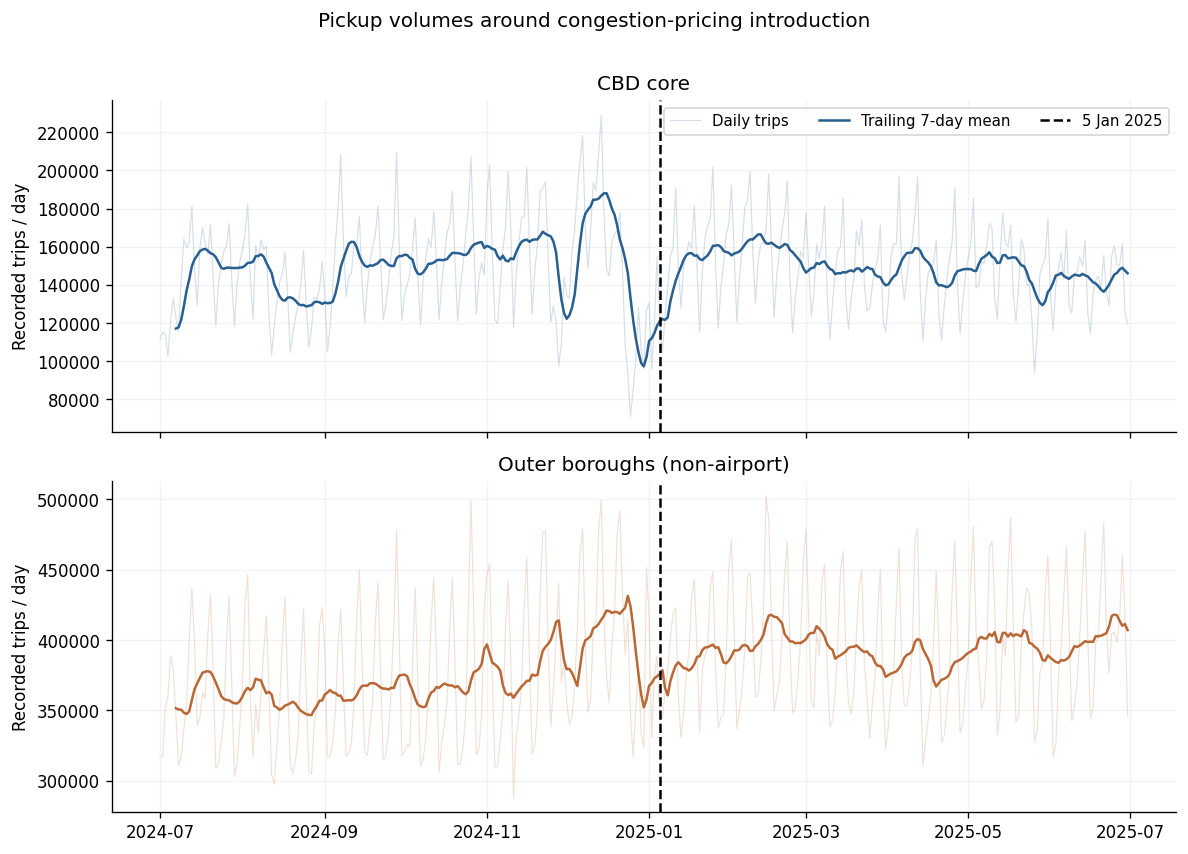

In [16]:
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})
COLORS = {'CBD core': '#285f91', 'Outer boroughs (non-airport)': '#b96835'}

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{name}.png', dpi=220, bbox_inches='tight')
    plt.show()

# Reindexing and rolling smoothing here operate on a few hundred daily totals.
daily_plot = daily_pd[daily_pd.area.isin(PRIMARY_AREAS)].copy()
daily_plot['pickup_date'] = pd.to_datetime(daily_plot['pickup_date'])
wide = daily_plot.pivot(index='pickup_date', columns='area', values='trips').sort_index()
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, area in zip(axes, PRIMARY_AREAS):
    ax.plot(wide.index, wide[area], color=COLORS[area], alpha=0.2, linewidth=0.7, label='Daily trips')
    ax.plot(wide.index, wide[area].rolling(7, min_periods=7).mean(), color=COLORS[area],
            label='Trailing 7-day mean')
    ax.axvline(pd.Timestamp(POLICY), color='black', linestyle='--', label='5 Jan 2025')
    ax.set(title=area, ylabel='Recorded trips / day')
    ax.grid(alpha=0.15)
axes[0].legend(ncol=3, fontsize=9)
fig.suptitle('Pickup volumes around congestion-pricing introduction', y=1.01)
save_figure(fig, '01_daily_pickups')


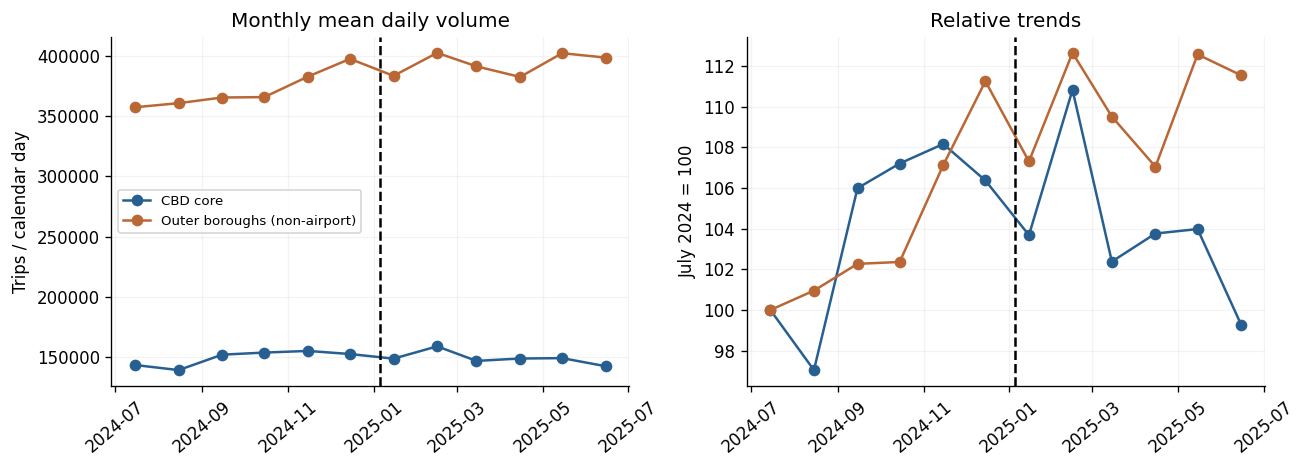

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for area in PRIMARY_AREAS:
    data = monthly_demand_pd[monthly_demand_pd.area == area].sort_values('month')
    x = pd.to_datetime(data.month + '-15')
    y = data.trips_per_day
    baseline = float(y.iloc[0])
    axes[0].plot(x, y, marker='o', color=COLORS[area], label=area)
    if baseline > 0:
        axes[1].plot(x, 100 * y / baseline, marker='o', color=COLORS[area], label=area)
for ax in axes:
    ax.axvline(pd.Timestamp(POLICY), color='black', linestyle='--')
    ax.tick_params(axis='x', rotation=40)
    ax.grid(alpha=0.15)
axes[0].set(title='Monthly mean daily volume', ylabel='Trips / calendar day')
axes[1].set(title='Relative trends', ylabel='July 2024 = 100')
axes[0].legend(fontsize=8)
save_figure(fig, '02_monthly_volume_and_index')


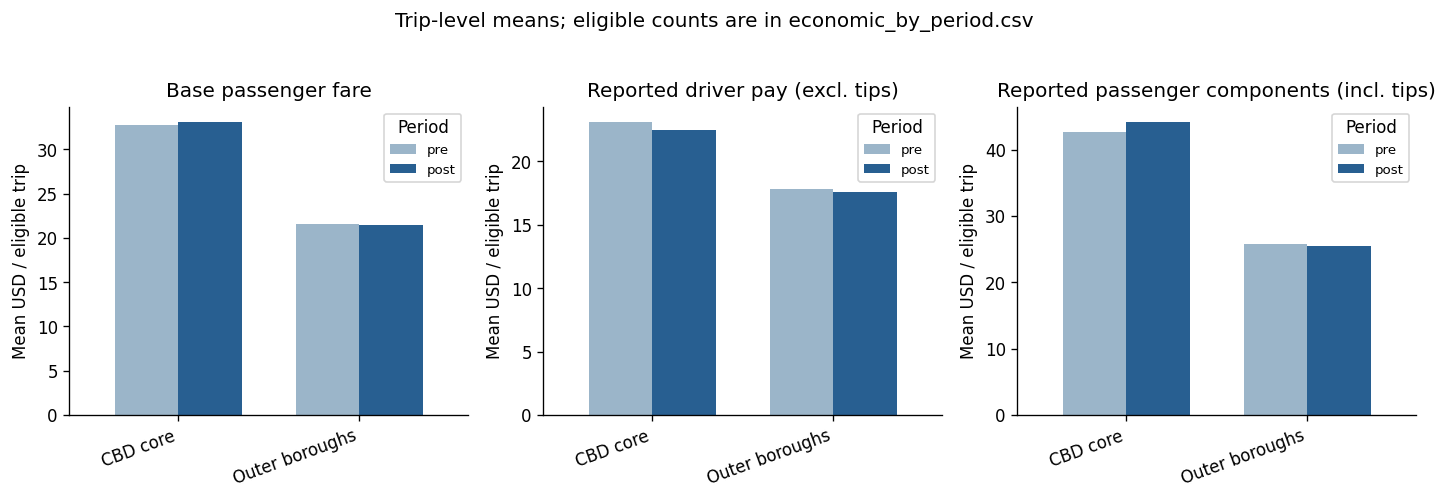

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric, label in zip(axes, ['avg_fare', 'avg_pay', 'avg_passenger_amount'],
    ['Base passenger fare', 'Reported driver pay (excl. tips)', 'Reported passenger components (incl. tips)']):
    data = metrics_pd.pivot(index='area', columns='period', values=metric).reindex(PRIMARY_AREAS)
    data = data.reindex(columns=['pre', 'post'])
    data.plot.bar(ax=ax, color=['#9bb5c9', '#285f91'], width=0.7)
    ax.set(title=label, ylabel='Mean USD / eligible trip', xlabel='')
    ax.set_xticklabels(['CBD core', 'Outer boroughs'], rotation=20, ha='right')
    ax.legend(title='Period', fontsize=8)
fig.suptitle('Trip-level means; eligible counts are in economic_by_period.csv', y=1.03)
save_figure(fig, '03_fare_pay_components')


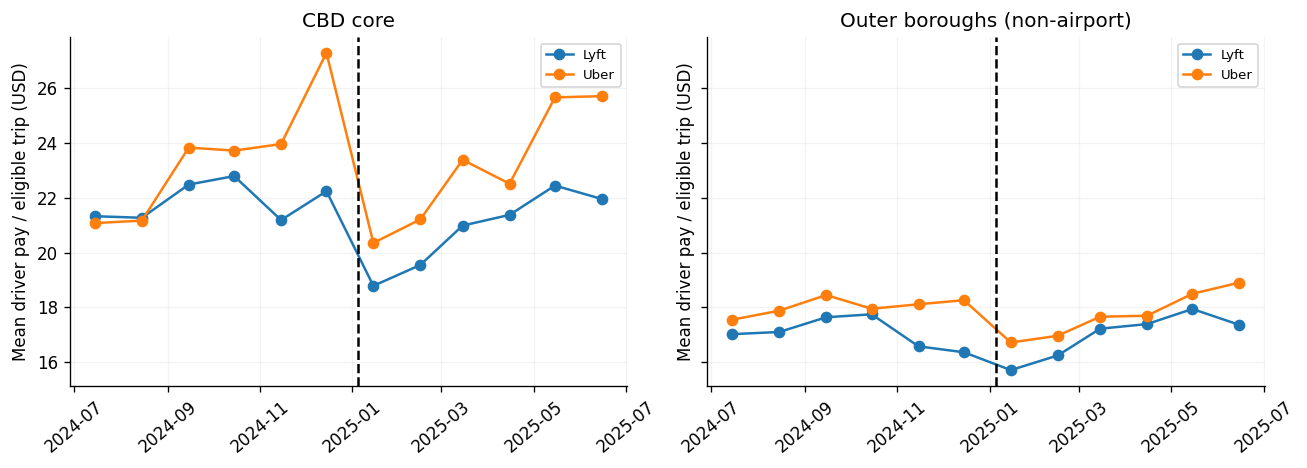

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, area in zip(axes, PRIMARY_AREAS):
    data = monthly_operator_pd[monthly_operator_pd.area == area].sort_values('month')
    for operator, rows in data.groupby('operator'):
        ax.plot(pd.to_datetime(rows.month + '-15'), rows.avg_pay, marker='o', label=operator)
    ax.axvline(pd.Timestamp(POLICY), color='black', linestyle='--')
    ax.set(title=area, ylabel='Mean driver pay / eligible trip (USD)')
    ax.tick_params(axis='x', rotation=40)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15)
save_figure(fig, '04_monthly_operator_pay')


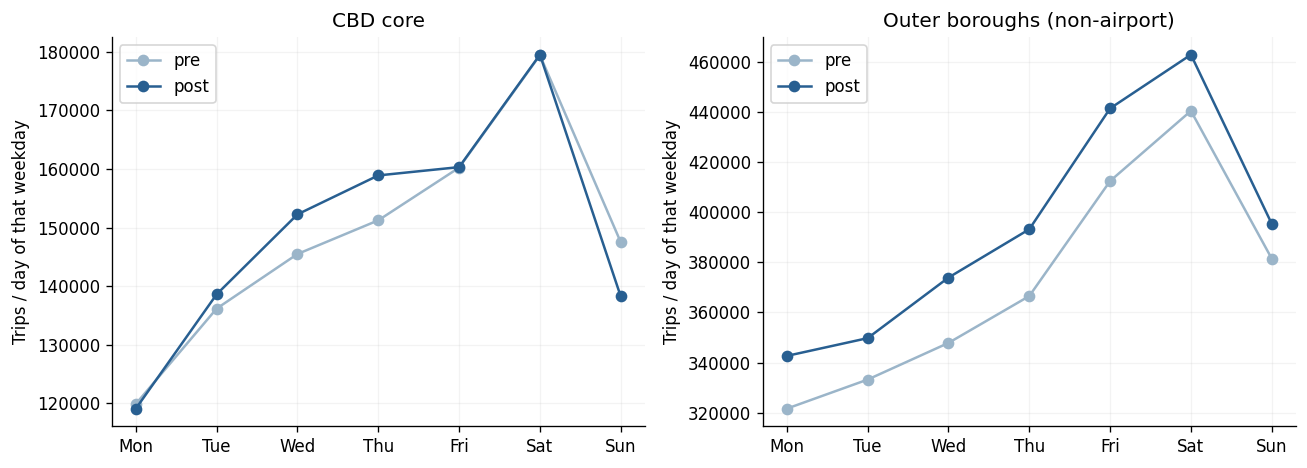

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, area in zip(axes, PRIMARY_AREAS):
    for period, color in [('pre', '#9bb5c9'), ('post', '#285f91')]:
        data = weekday_pd[(weekday_pd.area == area) & (weekday_pd.period == period)]
        values = data.set_index('weekday').reindex([2, 3, 4, 5, 6, 7, 1]).trips_per_day
        ax.plot(range(7), values, marker='o', label=period, color=color)
    ax.set_xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax.set(title=area, ylabel='Trips / day of that weekday')
    ax.legend()
    ax.grid(alpha=0.15)
save_figure(fig, '05_weekday_demand')


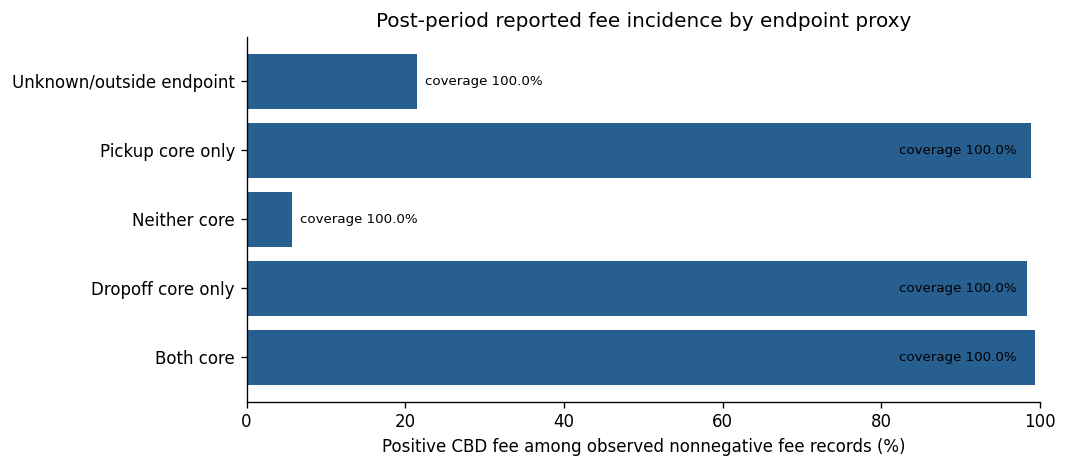

Figures saved: ['01_daily_pickups.pdf', '01_daily_pickups.png', '02_monthly_volume_and_index.pdf', '02_monthly_volume_and_index.png', '03_fare_pay_components.pdf', '03_fare_pay_components.png', '04_monthly_operator_pay.pdf', '04_monthly_operator_pay.png', '05_weekday_demand.pdf', '05_weekday_demand.png', '06_fee_incidence.pdf', '06_fee_incidence.png']


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
fee_plot = fees_pd.sort_values('endpoint_group')
ax.barh(fee_plot.endpoint_group, fee_plot.positive_fee_pct_observed, color='#285f91')
ax.set(xlabel='Positive CBD fee among observed nonnegative fee records (%)',
       title='Post-period reported fee incidence by endpoint proxy', xlim=(0, 100))
for i, (_, row) in enumerate(fee_plot.iterrows()):
    value = row.positive_fee_pct_observed
    if pd.notna(value):
        ax.text(min(value + 1, 97), i, f"coverage {row.fee_coverage_pct:.1f}%", va='center', fontsize=8,
                ha='right' if value > 80 else 'left')
save_figure(fig, '06_fee_incidence')
print('Figures saved:', sorted(p.name for p in FIG_DIR.iterdir()))


## 11. Interpretation after the run
Use the printed results and CSVs to write the findings. No conclusions about the direction or size of changes have been filled in in advance.

1. Compare daily pickup rates and the relative-change contrast. Describe whether the daily/monthly curves suggest an abrupt change, a gradual trend or little separation. Check the 28-day and weekday comparisons before relying on pooled periods.
2. Compare mean and median base fare and driver pay, with their eligible counts. Use average distance, duration and distance bands to assess changing trip mix. Do not interpret pay per trip as driver hourly earnings, platform profit or a passenger-payment share.
3. Check operator-specific trends and fee coverage. Explain why neither-core trips can still show a fee, and whether the pickup proxy misses relevant charged journeys.
4. Connect the observed patterns to decisions. Sustained volume changes could inform fleet positioning; trip-mix and pay changes could help operators or driver representatives monitor remuneration; reported fee coverage could support charge transparency. None establishes improved congestion, a shift to public transport or equitable outcomes without other data.

The main limitations are seasonality and holidays, different regional trip mixes, spillovers into comparison areas, a conservative zone proxy rather than route-level exposure, and self-reported trip records. HVFHV counts represent recorded completed activity, not requests, unmet demand, passenger numbers or all travel. Driver identifiers, operating expenses and unpaid time are unavailable. Means can be influenced by extreme values even after plausibility filtering. Colab also limits the compute-scale claims we can make.

For the technical interpretation, relate the scan/partition counts, aggregation keys, shuffle and observed stage behaviour to the small outputs obtained. Report the measured input size and runtime, and distinguish observed performance from hypothetical benefits on a cluster.


## 12. Save the run and capture evidence
Before the last cell:

- Save the executed notebook with its real outputs in Colab.
- Screenshot the actual input-size/row-count output, the RDD lineage and the physical plan.
- Open the Spark UI while the session is alive. Save the named RDD job DAG, stage details showing tasks and shuffle read/write, and SQL plan for the month × area × operator aggregation. Place screenshots in `output/evidence/` through the Colab file panel. Record application/job/stage IDs so screenshots can be matched to this run.
- Review the zone-definition CSV and discuss the conservative proxy in the report. If a more precise official CBD-to-zone crosswalk becomes available, rerun using that crosswalk and document boundary treatment.
- Write results from the run. The assignment also needs a 5–7 page report including figures (up to two extra appendix pages), repository link and a video of no more than ten minutes. The notebook does not replace those deliverables.

The final cell stops Spark to close the event log and packages figures, aggregated CSVs and evidence. Overleaf needs the PDFs from `figures/`. Raw data is excluded from the archive and should not be committed to GitHub. Upload this notebook and the run instructions with the existing Part 1 project.


In [22]:
# Run only after capturing the live Spark UI. Earlier cells require a live session.
daily.unpersist()
spark.stop()
import zipfile
archive = PROJECT_ROOT / 'MIT805_Part2_results.zip'
with zipfile.ZipFile(archive, 'w', compression=zipfile.ZIP_DEFLATED) as z:
    for folder in [FIG_DIR, OUT_DIR]:
        for path in folder.rglob('*'):
            if path.is_file():
                z.write(path, path.relative_to(PROJECT_ROOT))
print('Results archive:', archive)
try:
    from google.colab import files
    files.download(str(archive))
except ImportError:
    print('Download the archive from the project output folder.')


Results archive: /content/mit805_part2/MIT805_Part2_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Sources
- MIT 805 Big Data Semester Project (2026), supplied assignment brief, Part 2 and rubric.
- Group 10, supplied Part 1 report and Polars notebook; dataset scale, working window and plausibility rules.
- [NYC TLC trip records and zone metadata](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).
- [HVFHV data dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_hvfhs.pdf), 18 March 2025.
- [MTA taxi/FHV per-trip charge explanation](https://www.mta.info/fares-tolls/tolls/congestion-relief-zone/taxi-fhv-tolls), for geographic exposure beyond pickup location.

Public TLC files can be revised. Preserve the downloaded manifest, schemas, run date and source URLs when documenting reproducibility.
